# Spatial Hotspot Analysis — KDE & Gaussian Mixture Models

This notebook identifies **spatial hotspots** of taxi activity in Chicago from the 10% sample (`02_merged_data_sample_10pct.parquet`), using two complementary density methods on the pickup and dropoff coordinates:

1. **Kernel Density Estimation (KDE)** — a smooth, non-parametric density surface showing *where* activity concentrates.
2. **Gaussian Mixture Models (GMM)** — a parametric model that summarises the same density as a handful of Gaussian *components*; each component's mean is a hotspot centre and its weight is the share of trips it captures. The number of components is chosen by **BIC**.

Both run for **pickups** and **dropoffs** separately (Pickup = left, Dropoff = right).

## Important caveat: coordinates are area centroids, not raw GPS

As established in `data_exploration.ipynb`, `*_lat`/`*_lon` are **centroids** of a census tract or community area, so the 10% sample contains only a few hundred *distinct* coordinates, each repeated for many trips. Two consequences shape the method below:

- **KDE** is fitted on the *unique* coordinates with `sample_weight` set to the trip count at each — this is both efficient and weights density by trip volume rather than by the number of distinct centroids.
- **GMM** has no sample-weighting, so we draw a volume-proportional subsample and add a small spatial **jitter** (≈ the centroid spacing). Without jitter the points are discrete spikes, which yields degenerate/singular covariances. The jitter also reflects that each centroid stands in for trips spread across a real area.

Distances/bandwidths are expressed in **degrees** (at Chicago's latitude, 0.01° ≈ 0.85 km E–W and ≈ 1.11 km N–S); the mild anisotropy is acceptable for locating hotspots.

In [ ]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import geopandas
import shapely
from sklearn.neighbors import KernelDensity
from sklearn.mixture import GaussianMixture

RANDOM_STATE = 42

## Load data

Only the pickup/dropoff coordinates are needed. We keep both raw points and, for KDE, a *weighted-unique* representation: the distinct centroids with the number of trips at each.

In [ ]:
_COORD_COLS = ["pickup_lat", "pickup_lon", "dropoff_lat", "dropoff_lon"]

df = pl.read_parquet("../data/02_merged_data_sample_10pct.parquet", columns=_COORD_COLS).to_pandas()
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


def coords(side):
    """Raw (lon, lat) array for one side ('pickup'/'dropoff'), NaNs dropped."""
    sub = df[[f"{side}_lon", f"{side}_lat"]].dropna()
    return sub.to_numpy()


def weighted_unique(side):
    """Distinct (lon, lat) centroids and the trip count (weight) at each."""
    sub = df[[f"{side}_lon", f"{side}_lat"]].dropna()
    g = sub.groupby([f"{side}_lon", f"{side}_lat"]).size().reset_index(name="w")
    return g[[f"{side}_lon", f"{side}_lat"]].to_numpy(), g["w"].to_numpy(dtype="float64")


for side in ("pickup", "dropoff"):
    xy, w = weighted_unique(side)
    print(f"{side:>7}: {int(w.sum()):>10,} trips across {len(xy):>4} distinct centroids")

Shape: 1,349,173 rows x 4 columns
 pickup:  1,349,173 trips across  386 distinct centroids


dropoff:  1,255,071 trips across  496 distinct centroids


## Community-area boundaries & city extent

The 77 community areas are used purely as a backdrop and, later, to *name* each hotspot. Their union is the city polygon, used to mask the KDE grid (so density is only drawn over Chicago) and to set the map extent.

In [ ]:
communities_gdf = geopandas.read_file("../data/chicago_community_boundaries.json")
communities_gdf["area_number"] = communities_gdf["area_numbe"].astype(int)
communities_gdf["community"] = communities_gdf["community"].str.title()
communities_gdf = communities_gdf[["area_number", "community", "geometry"]].set_crs("EPSG:4326")

city_poly = communities_gdf.union_all()
XMIN, YMIN, XMAX, YMAX = communities_gdf.total_bounds
print(f"{len(communities_gdf)} community areas; "
      f"extent lon [{XMIN:.3f}, {XMAX:.3f}], lat [{YMIN:.3f}, {YMAX:.3f}]")

77 community areas; extent lon [-87.940, -87.524], lat [41.645, 42.023]


## 1. Kernel Density Estimation

A Gaussian KDE is fitted on the **weighted-unique** centroids of each side, then evaluated on a regular grid that is masked to the city polygon. The result is a smooth surface whose value is proportional to trip density; the brightest regions are the hotspots.

`BANDWIDTH` (in degrees) controls smoothing: too small and the surface breaks into one blob per centroid, too large and distinct hotspots merge. ≈ 0.006° (≈ 600 m) is a reasonable compromise given the centroid spacing — adjust to taste.

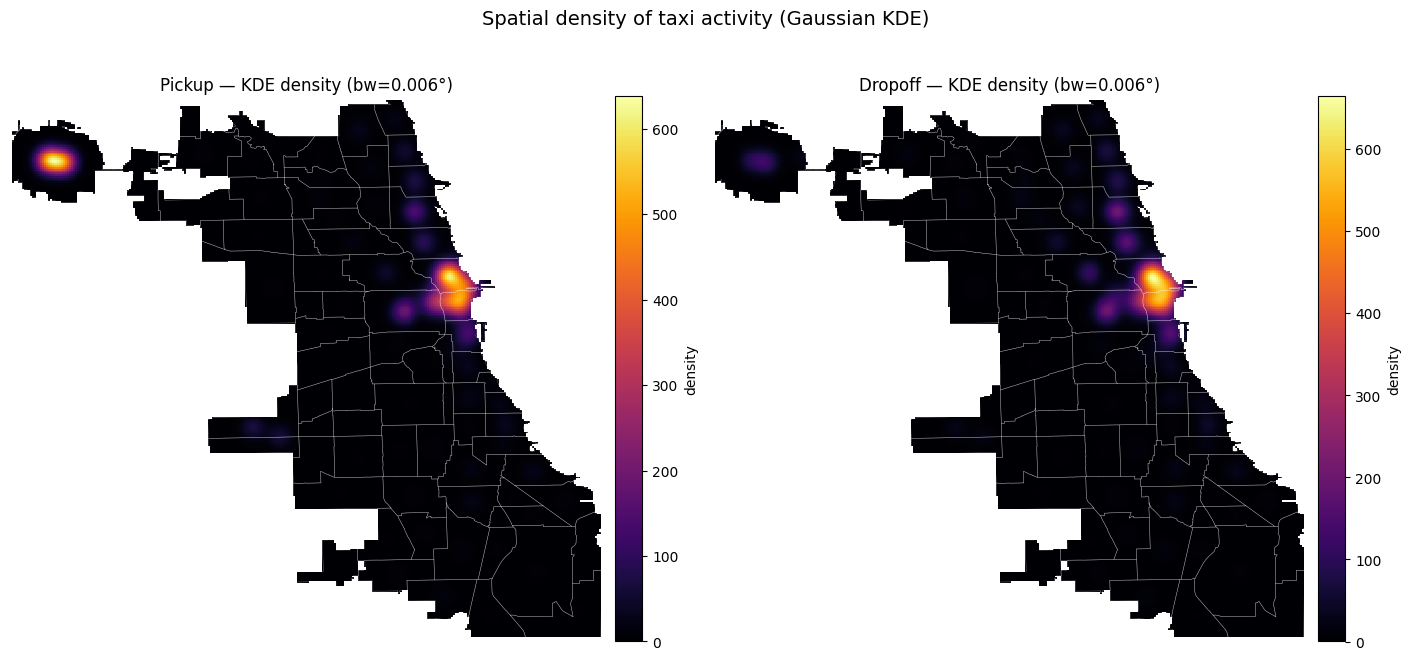

In [ ]:
BANDWIDTH = 0.006   # degrees (~600 m); smoothing scale of the KDE
GRID_SIZE = 300     # grid resolution per axis for evaluating the density

# Grid over the city extent, masked to the actual Chicago polygon.
_xs = np.linspace(XMIN, XMAX, GRID_SIZE)
_ys = np.linspace(YMIN, YMAX, GRID_SIZE)
_XX, _YY = np.meshgrid(_xs, _ys)
_grid = np.column_stack([_XX.ravel(), _YY.ravel()])
_inside = shapely.contains_xy(city_poly, _grid[:, 0], _grid[:, 1])


def kde_surface(side, bandwidth=BANDWIDTH):
    """Volume-weighted Gaussian KDE evaluated on the masked city grid."""
    xy, w = weighted_unique(side)
    kde = KernelDensity(bandwidth=bandwidth, kernel="gaussian").fit(xy, sample_weight=w)
    dens = np.full(_grid.shape[0], np.nan)
    dens[_inside] = np.exp(kde.score_samples(_grid[_inside]))
    return dens.reshape(_XX.shape)


fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
for ax, side in zip(axes, ("pickup", "dropoff")):
    Z = kde_surface(side)
    mesh = ax.pcolormesh(_XX, _YY, np.ma.masked_invalid(Z), cmap="inferno", shading="auto")
    communities_gdf.boundary.plot(ax=ax, color="white", linewidth=0.3, alpha=0.5)
    fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.02, label="density")
    ax.set_title(f"{side.title()} — KDE density (bw={BANDWIDTH}°)")
    ax.set_aspect("equal")
    ax.set_axis_off()
fig.suptitle("Spatial density of taxi activity (Gaussian KDE)", fontsize=14)
plt.show()

## 2. Gaussian Mixture Models

A GMM describes the point cloud as a sum of `K` 2-D Gaussians. Each component is a candidate hotspot: its **mean** is the centre, its **covariance** the spread/orientation, and its **weight** the fraction of trips it explains.

### Building the fitting sample

`GaussianMixture` cannot take sample weights, so we draw a **volume-proportional** subsample of the centroids (so dense areas contribute more points) and add Gaussian **jitter** (≈ the centroid spacing) so the points form continuous clouds rather than discrete spikes — otherwise covariances collapse to ~0.

### Choosing K

We fit a range of `K` and pick the one minimising **BIC** (Bayesian Information Criterion), which rewards fit and penalises extra components.

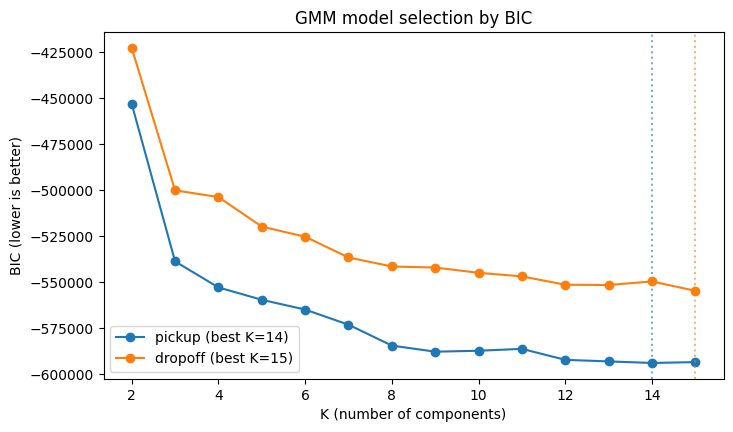

Selected K: {'pickup': 14, 'dropoff': 15}


In [ ]:
SUBSAMPLE = 60_000   # points drawn (with replacement) for GMM fitting
JITTER = 0.004       # degrees of Gaussian noise added to spread centroids
K_RANGE = range(2, 16)

_rng = np.random.default_rng(RANDOM_STATE)


def gmm_sample(side, n=SUBSAMPLE, jitter=JITTER):
    """Volume-proportional, jittered point sample for GMM fitting."""
    xy, w = weighted_unique(side)
    idx = _rng.choice(len(xy), size=n, replace=True, p=w / w.sum())
    return xy[idx] + _rng.normal(0.0, jitter, size=(n, 2))


def select_k(sample, k_range=K_RANGE):
    """Fit a GMM for each K and return (bics, best_k)."""
    bics = []
    for k in k_range:
        gm = GaussianMixture(k, covariance_type="full", random_state=RANDOM_STATE).fit(sample)
        bics.append(gm.bic(sample))
    best_k = list(k_range)[int(np.argmin(bics))]
    return np.array(bics), best_k


samples = {side: gmm_sample(side) for side in ("pickup", "dropoff")}

fig, ax = plt.subplots(figsize=(8, 4.5))
best_k = {}
for side in ("pickup", "dropoff"):
    bics, k = select_k(samples[side])
    best_k[side] = k
    ax.plot(list(K_RANGE), bics, marker="o", label=f"{side} (best K={k})")
    ax.axvline(k, color=ax.lines[-1].get_color(), linestyle=":", alpha=0.6)
ax.set_xlabel("K (number of components)")
ax.set_ylabel("BIC (lower is better)")
ax.set_title("GMM model selection by BIC")
ax.legend()
plt.show()
print("Selected K:", best_k)

### Fitting the selected models & mapping the hotspots

Each side is refitted with its BIC-selected `K`. Every component is drawn as a covariance **ellipse** (2σ) centred on its mean, over the community boundaries; the ellipse is shaded by the component **weight** (share of trips), and the highest-weight centres are the dominant hotspots.

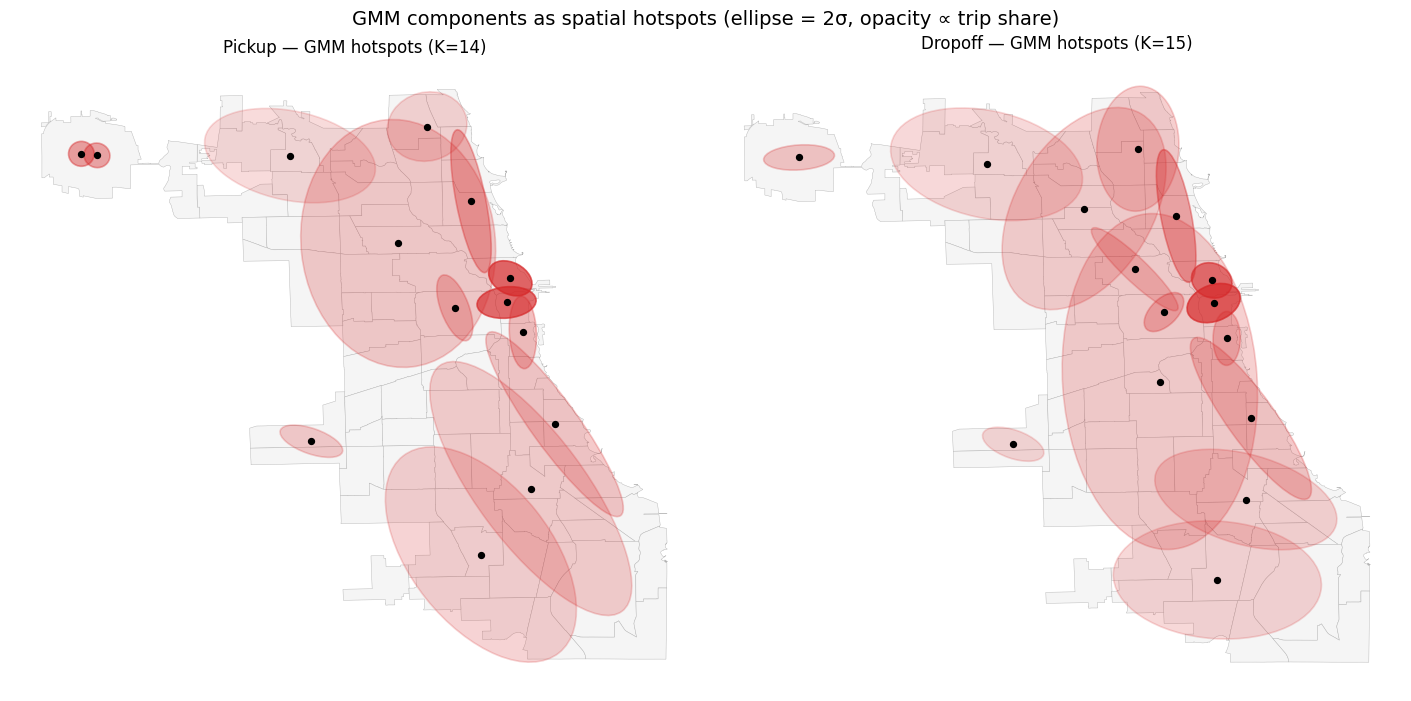

In [ ]:
def fit_gmm(side):
    return GaussianMixture(best_k[side], covariance_type="full",
                           random_state=RANDOM_STATE).fit(samples[side])


gmms = {side: fit_gmm(side) for side in ("pickup", "dropoff")}


def draw_ellipse(ax, mean, cov, weight, wmax, color):
    """Draw a 2-sigma covariance ellipse, opacity scaled by component weight."""
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * 2 * np.sqrt(vals)   # 2-sigma full axis lengths
    ax.add_patch(Ellipse(mean, width, height, angle=angle,
                         facecolor=color, edgecolor=color,
                         alpha=0.15 + 0.55 * weight / wmax, linewidth=1.2))


fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
for ax, side in zip(axes, ("pickup", "dropoff")):
    gm = gmms[side]
    wmax = gm.weights_.max()
    communities_gdf.plot(ax=ax, color="whitesmoke", edgecolor="0.7", linewidth=0.3)
    for mean, cov, weight in zip(gm.means_, gm.covariances_, gm.weights_):
        draw_ellipse(ax, mean, cov, weight, wmax, "tab:red")
    ax.scatter(gm.means_[:, 0], gm.means_[:, 1], s=18, color="black", zorder=5)
    ax.set_title(f"{side.title()} — GMM hotspots (K={best_k[side]})")
    ax.set_aspect("equal")
    ax.set_axis_off()
fig.suptitle("GMM components as spatial hotspots (ellipse = 2σ, opacity ∝ trip share)", fontsize=14)
plt.show()

## 3. Ranked hotspots

Each GMM component mean is located within a community area (point-in-polygon) to give the hotspot a name, then ranked by weight — the estimated share of that side's trips it captures.

In [ ]:
def hotspot_table(side):
    gm = gmms[side]
    pts = geopandas.GeoDataFrame(
        {"weight": gm.weights_},
        geometry=geopandas.points_from_xy(gm.means_[:, 0], gm.means_[:, 1]),
        crs="EPSG:4326",
    )
    named = geopandas.sjoin(pts, communities_gdf, predicate="within", how="left")
    named = named.drop_duplicates(subset="geometry")
    out = pd.DataFrame({
        "side": side,
        "community": named["community"].fillna("(outside city)").to_numpy(),
        "lon": gm.means_[:, 0].round(4),
        "lat": gm.means_[:, 1].round(4),
        "trip_share": named["weight"].to_numpy(),
    })
    return out.sort_values("trip_share", ascending=False).reset_index(drop=True)


hotspots = pd.concat([hotspot_table("pickup"), hotspot_table("dropoff")], ignore_index=True)
hotspots["trip_share"] = (hotspots["trip_share"] * 100).round(1).astype(str) + "%"
hotspots

,side,community,lon,lat,trip_share
0,pickup,Near North Side,-87.6286,41.8975,22.2%
1,pickup,Loop,-87.6310,41.8815,21.2%
2,pickup,Ohare,-87.9135,41.9802,11.1%
3,pickup,Ohare,-87.9031,41.9792,10.1%
4,pickup,Lake View,-87.6547,41.9487,8.4%
5,pickup,Near South Side,-87.6202,41.8616,5.7%
6,pickup,Near West Side,-87.6654,41.8779,4.9%
7,pickup,Hyde Park,-87.5992,41.8006,3.7%
8,pickup,Logan Square,-87.7030,41.9207,3.1%
9,pickup,Garfield Ridge,-87.7607,41.7893,3.0%


## Takeaways

- The **KDE** surfaces show where trip density concentrates; for Chicago taxis this is dominated by the **central business district / Loop & Near North** and **O'Hare/Midway airports**.
- The **GMM** reduces that surface to a small set of interpretable hotspots, each with a centre, an extent (the 2σ ellipse) and a **trip share** — the ranked table names the dominant pickup and dropoff hotspots.
- Because the coordinates are **area centroids**, these hotspots are accurate to community-area resolution, not street level; the KDE bandwidth and GMM jitter encode that uncertainty. Pickups are typically more concentrated (airports + Loop) than dropoffs, which spread further into residential areas.

**Knobs to explore:** `BANDWIDTH` (KDE smoothing), `K_RANGE`/BIC (number of hotspots), and `JITTER`/`SUBSAMPLE` (GMM fitting). Switching the analysis to a projected CRS (e.g. EPSG:3435) would remove the slight lon/lat anisotropy if metric precision is needed.